# Composite Market Risk Indicator

> **Live-data notebook.** Run all cells from top to bottom. One UTC timestamp is shared across the VIX, SKEW, CAPE, and composite calculations; saved outputs represent the latest committed execution.


Notebook run timestamp (UTC): 2026-07-30T11:08:48.576948+00:00


As of: 2026-07-30

VIX latest daily date used: 2026-07-30
VIX latest value used as current-month close: 19.44

SKEW latest daily date used: 2026-07-29
SKEW latest value used as current-month close: 139.55

----- VIX Bubble Risk -----
Model date: 2026-07-31
Latest value: 19.44
Risk: 40.66 %
Display sigma: -0.2363 SIG
Raw Z: 0.2363
Deviation: 0.033941
Deviation 10Y Avg: 0.004658
Deviation 10Y Std: 0.123938

----- SKEW Risk -----
Model date: 2026-07-31
Latest value: 139.55
Risk: 31.19 %
Display sigma: -0.4904 SIG
Raw Z: -0.4904
Deviation: 0.004597
Deviation 10Y Avg: 0.013116
Deviation 10Y Std: 0.017372

----- Valuation Risk -----
Model date: 2026-07-29
Latest value: 39.93
Risk: 62.67 %
Display sigma: 0.3232 SIG
Raw Z: 0.3232
Deviation: 0.232912
Deviation 10Y Avg: 0.194418
Deviation 10Y Std: 0.119119

----- Composite Risk -----
Model date: 2026-07-30
Risk: 44.84 %
Display sigma: -0.1297 SIG
Raw Z: -0.1297



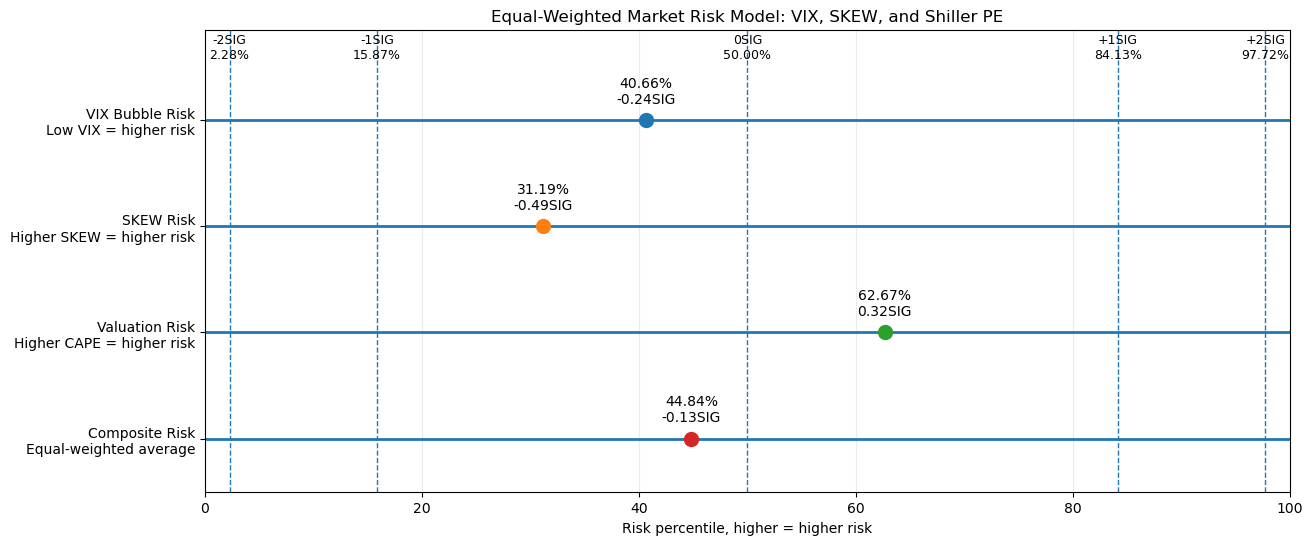

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path
import sys
from scipy.stats import norm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.market_risk.cape import compute_cape_risk_frame
from src.market_risk.skew import compute_skew_risk_frame
from src.market_risk.vix import compute_vix_risk_frame

# ============================================================
# 3-Factor Market Risk Model
#
# 1. VIX Bubble Risk
#    - VIX and SKEW are treated as approximately log-normal.
#    - VIX: low VIX = complacency / bubble risk high.
#    - Risk = 1 - NORMDIST(...)
#
# 2. SKEW Risk
#    - Log SKEW is used.
#    - SKEW has structural post-GFC trend change, so Step 3 trend correction matters.
#    - Higher SKEW = higher tail-risk pricing.
#    - Risk = NORMDIST(...)
#
# 3. Shiller PE / CAPE Valuation Risk
#    - CAPE itself is used, not log CAPE.
#    - Higher CAPE = higher valuation risk.
#    - Risk = NORMDIST(...)
#
# 4. Composite Risk
#    - Equal-weighted average of the three risk percentiles.
# ============================================================

# -------------------------
# Settings
# -------------------------

RUN_TIMESTAMP_UTC = pd.Timestamp.now(tz="UTC")
today = RUN_TIMESTAMP_UTC.tz_localize(None).normalize()
print(f"Notebook run timestamp (UTC): {RUN_TIMESTAMP_UTC.isoformat()}")

# Step2 and Step3 each use 10-year rolling windows.
# To calculate the latest risk, around 20 years of data is needed.
# 21 years gives a small buffer.
start_date = today - relativedelta(years=21)

ROLLING_MONTHS = 120


# ============================================================
# Helper 1: Get monthly close from yfinance daily data
# Past months: monthly close
# Current month: latest daily close used as provisional monthly close
# ============================================================

def get_monthly_from_yfinance(ticker, close_name):
    daily = yf.download(
        ticker,
        start=start_date.strftime("%Y-%m-%d"),
        end=(today + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        interval="1d",
        auto_adjust=False,
        progress=False
    )

    if isinstance(daily.columns, pd.MultiIndex):
        daily.columns = daily.columns.get_level_values(0)

    daily = daily[["Close"]].dropna()
    daily = daily.rename(columns={"Close": close_name})

    latest_date = daily.index[-1]
    latest_value = daily[close_name].iloc[-1]

    monthly = daily.resample("ME").last()

    # Use latest daily close as provisional current-month close
    current_month_end = today + pd.offsets.MonthEnd(0)
    monthly.loc[current_month_end, close_name] = latest_value

    monthly = monthly.sort_index()

    return monthly, latest_date, latest_value


# ============================================================
# Helper 2: VIX Bubble Risk
#
# Step 1: Log VIX
# Step 2: Deviation = (Log VIX - 10Y Log Avg) / 10Y Log Avg
# Step 3: 10Y rolling average and stdev of deviation
# Step 4: VIX Bubble Risk = 1 - NORMDIST(...)
#
# Low VIX = higher complacency / bubble risk
# Display sigma is reversed so that higher sigma = higher bubble risk
# ============================================================

def calc_vix_bubble_risk(monthly, value_col):
    df = compute_vix_risk_frame(
        monthly,
        value_col=value_col,
        window=ROLLING_MONTHS,
    )

    # VIX is inverted:
    # lower VIX = higher bubble/complacency risk
    df["Risk"] = 1 - df["Normal_Risk_Score"]

    latest = df.dropna(subset=["Z_Score"]).iloc[-1]

    return {
        "name": "VIX Bubble Risk",
        "risk_pct": float(latest["Risk"] * 100),
        "display_sigma": float(-latest["Z_Score"]),
        "raw_z": float(latest["Z_Score"]),
        "latest_value": float(latest[value_col]),
        "model_date": latest.name.date(),
        "deviation": float(latest["Log_Deviation"]),
        "dev_avg": float(latest["Dev_10Y_Avg"]),
        "dev_std": float(latest["Dev_10Y_Std"])
    }


# ============================================================
# Helper 3: Log-based high-risk index
#
# Used for SKEW.
# Higher value = higher risk.
#
# Step 1: Log value
# Step 2: Deviation = (Log value - 10Y Log Avg) / 10Y Log Avg
# Step 3: 10Y rolling average and stdev of deviation
# Step 4: Risk = NORMDIST(...)
# ============================================================

def calc_log_high_risk(monthly, value_col, name):
    df = compute_skew_risk_frame(
        monthly,
        value_col=value_col,
        window=ROLLING_MONTHS,
    )

    latest = df.dropna(subset=["Z_Score"]).iloc[-1]

    return {
        "name": name,
        "risk_pct": float(latest["Normal_Risk_Score"] * 100),
        "display_sigma": float(latest["Z_Score"]),
        "raw_z": float(latest["Z_Score"]),
        "latest_value": float(latest[value_col]),
        "model_date": latest.name.date(),
        "deviation": float(latest["Log_Deviation"]),
        "dev_avg": float(latest["Dev_10Y_Avg"]),
        "dev_std": float(latest["Dev_10Y_Std"])
    }


# ============================================================
# Helper 4: Get Shiller PE / CAPE from Multpl
# ============================================================

def get_cape_monthly_from_multpl():
    url = "https://www.multpl.com/shiller-pe/table/by-month"

    tables = pd.read_html(url)
    cape = tables[0].copy()
    cape.columns = ["Date", "CAPE"]

    cape["Date"] = pd.to_datetime(cape["Date"], errors="coerce")

    cape["CAPE"] = (
        cape["CAPE"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.extract(r"([0-9]+\.?[0-9]*)")[0]
        .astype(float)
    )

    cape = cape.dropna().sort_values("Date")
    cape["Month"] = cape["Date"].dt.to_period("M")
    cape = cape.drop_duplicates("Month", keep="last")
    cape = cape.set_index("Date")[["CAPE"]]

    return cape


# ============================================================
# Helper 5: CAPE Valuation Risk
#
# Step 1: Deviation = (CAPE - 10Y Avg CAPE) / 10Y Avg CAPE
# Step 2: 10Y rolling average and stdev of deviation
# Step 3: Valuation Risk = NORMDIST(...)
#
# Higher CAPE = higher valuation risk
# ============================================================

def calc_cape_valuation_risk(monthly, value_col="CAPE"):
    df = compute_cape_risk_frame(
        monthly,
        value_col=value_col,
        window=ROLLING_MONTHS,
    )
    latest = df.dropna(subset=["Z_Score"]).iloc[-1]

    return {
        "name": "Valuation Risk",
        "risk_pct": float(latest["Normal_Risk_Score"] * 100),
        "display_sigma": float(latest["Z_Score"]),
        "raw_z": float(latest["Z_Score"]),
        "latest_value": float(latest[value_col]),
        "model_date": latest.name.date(),
        "deviation": float(latest["CAPE_Deviation"]),
        "dev_avg": float(latest["Dev_10Y_Avg"]),
        "dev_std": float(latest["Dev_10Y_Std"])
    }


# ============================================================
# Data fetch
# ============================================================

vix_monthly, vix_latest_date, vix_latest_value = get_monthly_from_yfinance(
    "^VIX",
    "VIX_Close"
)

skew_monthly, skew_latest_date, skew_latest_value = get_monthly_from_yfinance(
    "^SKEW",
    "SKEW_Close"
)

cape_monthly = get_cape_monthly_from_multpl()


# ============================================================
# Risk calculations
# ============================================================

vix_result = calc_vix_bubble_risk(vix_monthly, "VIX_Close")

skew_result = calc_log_high_risk(
    skew_monthly,
    "SKEW_Close",
    "SKEW Risk"
)

cape_result = calc_cape_valuation_risk(
    cape_monthly,
    "CAPE"
)

base_results = [vix_result, skew_result, cape_result]


# ============================================================
# Equal-weighted composite
# ============================================================

composite_risk = np.mean([r["risk_pct"] for r in base_results])

# Convert percentile back into sigma
composite_sigma = norm.ppf(composite_risk / 100)

composite_result = {
    "name": "Composite Risk",
    "risk_pct": float(composite_risk),
    "display_sigma": float(composite_sigma),
    "raw_z": float(composite_sigma),
    "latest_value": np.nan,
    "model_date": today.date(),
    "deviation": np.nan,
    "dev_avg": np.nan,
    "dev_std": np.nan
}

results = base_results + [composite_result]


# ============================================================
# Print summary
# ============================================================

print("As of:", today.date())
print()

print("VIX latest daily date used:", vix_latest_date.date())
print("VIX latest value used as current-month close:", round(float(vix_latest_value), 4))
print()

print("SKEW latest daily date used:", skew_latest_date.date())
print("SKEW latest value used as current-month close:", round(float(skew_latest_value), 4))
print()

for r in results:
    print("-----", r["name"], "-----")
    print("Model date:", r["model_date"])

    if not np.isnan(r["latest_value"]):
        print("Latest value:", round(r["latest_value"], 4))

    print("Risk:", round(r["risk_pct"], 2), "%")
    print("Display sigma:", round(r["display_sigma"], 4), "SIG")
    print("Raw Z:", round(r["raw_z"], 4))

    if not np.isnan(r["deviation"]):
        print("Deviation:", round(r["deviation"], 6))
        print("Deviation 10Y Avg:", round(r["dev_avg"], 6))
        print("Deviation 10Y Std:", round(r["dev_std"], 6))

    print()


# ============================================================
# Combined visualization
# ============================================================

sigma_levels = {
    "-2SIG": norm.cdf(-2) * 100,
    "-1SIG": norm.cdf(-1) * 100,
    "0SIG":  norm.cdf(0) * 100,
    "+1SIG": norm.cdf(1) * 100,
    "+2SIG": norm.cdf(2) * 100,
}

y_positions = {
    "VIX Bubble Risk": 4,
    "SKEW Risk": 3,
    "Valuation Risk": 2,
    "Composite Risk": 1,
}

y_labels = [
    "VIX Bubble Risk\nLow VIX = higher risk",
    "SKEW Risk\nHigher SKEW = higher risk",
    "Valuation Risk\nHigher CAPE = higher risk",
    "Composite Risk\nEqual-weighted average"
]

plt.figure(figsize=(14, 6))

# Horizontal risk lines and current points
for r in results:
    y = y_positions[r["name"]]

    plt.hlines(y, 0, 100, linewidth=2)
    plt.plot(r["risk_pct"], y, marker="o", markersize=10)

    plt.text(
        r["risk_pct"],
        y + 0.13,
        f"{r['risk_pct']:.2f}%\n{r['display_sigma']:.2f}SIG",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Sigma reference lines
for label, x in sigma_levels.items():
    plt.axvline(x, linestyle="--", linewidth=1)

    plt.text(
        x,
        4.55,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.yticks(
    [4, 3, 2, 1],
    y_labels
)

plt.xlim(0, 100)
plt.ylim(0.5, 4.85)
plt.xlabel("Risk percentile, higher = higher risk")
plt.title("Equal-Weighted Market Risk Model: VIX, SKEW, and Shiller PE")
plt.grid(axis="x", alpha=0.25)

plt.show()

=== VIX Bubble Risk Latest Value ===
As of: 2026-07-30
Latest VIX date used: 2026-07-30
Latest VIX used as current-month close: 19.4400
Model month: 2026-07-31

Log Deviation: 0.033941
Deviation 10Y Avg: 0.004658
Deviation 10Y Std: 0.123938

Raw Z-score: 0.2363
Display Sigma: -0.2363
VIX Bubble Risk: 40.66%

=== Sigma Reference ===
-2SIG: 2.28%
-1SIG: 15.87%
0SIG: 50.00%
+1SIG: 84.13%
+2SIG: 97.72%


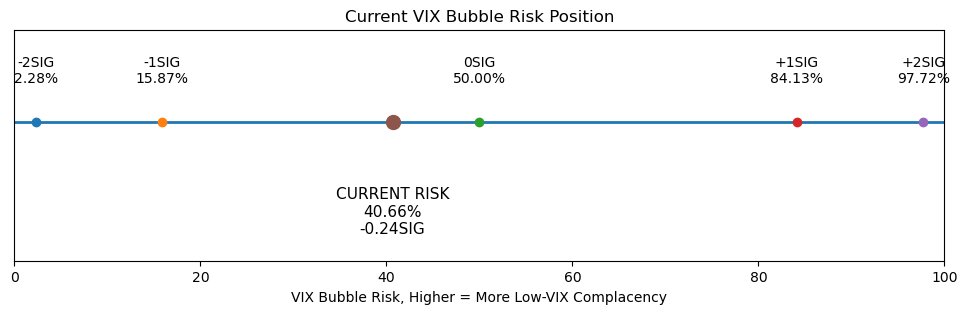

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# =========================
# VIX Bubble Risk Model
# Completed months use month-end closes.
# The current month uses the latest available VIX close as a provisional month-end close.
# Risk increases as VIX falls.
# Positive display sigma indicates higher bubble risk.
# =========================

# Current date
today = RUN_TIMESTAMP_UTC.tz_localize(None).normalize()

# Download 21 years because Steps 2 and 3 each require a 10-year rolling window.
start_date = today - relativedelta(years=21)

# Download daily VIX data
daily = yf.download(
    "^VIX",
    start=start_date.strftime("%Y-%m-%d"),
    end=(today + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Flatten yfinance MultiIndex columns when present
if isinstance(daily.columns, pd.MultiIndex):
    daily.columns = daily.columns.get_level_values(0)

# Use only the Close column
daily = daily[["Close"]].dropna()
daily = daily.rename(columns={"Close": "VIX_Close"})

# Latest available VIX close
latest_date = daily.index[-1]
latest_vix = daily["VIX_Close"].iloc[-1]

# Build the monthly close series
monthly = daily.resample("ME").last()

# Use the latest available VIX close as the provisional close for the current month.
current_month_end = today + pd.offsets.MonthEnd(0)
monthly.loc[current_month_end, "VIX_Close"] = latest_vix
monthly = monthly.sort_index()

# Step 1: Log VIX
monthly["Log_VIX"] = np.log(monthly["VIX_Close"])

# Step 2: 10-year rolling mean of log values
monthly["Log_10Y_Avg"] = monthly["Log_VIX"].rolling(120).mean()

# Step 2: Relative deviation from the rolling log mean
monthly["Log_Deviation"] = (
    monthly["Log_VIX"] - monthly["Log_10Y_Avg"]
) / monthly["Log_10Y_Avg"]

# Step 3: 10-year rolling mean and standard deviation of the deviation
monthly["Dev_10Y_Avg"] = monthly["Log_Deviation"].rolling(120).mean()
monthly["Dev_10Y_Std"] = monthly["Log_Deviation"].rolling(120).std()

# Raw z-score
monthly["Raw_Z"] = (
    monthly["Log_Deviation"] - monthly["Dev_10Y_Avg"]
) / monthly["Dev_10Y_Std"]

# Step 4: VIX Risk = 1 - NORMDIST
# Lower VIX implies greater complacency and bubble risk.
monthly["VIX_Bubble_Risk"] = 1 - norm.cdf(monthly["Raw_Z"])

# Display sigma
# Reverse the Raw_Z sign so higher display values indicate higher risk.
monthly["Display_Sigma"] = -monthly["Raw_Z"]

# Latest complete model row
latest_row = monthly.dropna().iloc[-1]

current_risk = float(latest_row["VIX_Bubble_Risk"]) * 100
display_sigma_current = float(latest_row["Display_Sigma"])
raw_z_current = float(latest_row["Raw_Z"])

# Display-sigma reference levels
# +2 SIG corresponds to the 97.72% high-risk percentile.
display_sigma_levels = {
    "-2SIG": (1 - norm.cdf(2)) * 100,
    "-1SIG": (1 - norm.cdf(1)) * 100,
    "0SIG":  (1 - norm.cdf(0)) * 100,
    "+1SIG": (1 - norm.cdf(-1)) * 100,
    "+2SIG": (1 - norm.cdf(-2)) * 100,
}

# =========================
# Display numeric results
# =========================

print("=== VIX Bubble Risk Latest Value ===")
print(f"As of: {today.date()}")
print(f"Latest VIX date used: {latest_date.date()}")
print(f"Latest VIX used as current-month close: {float(latest_vix):.4f}")
print(f"Model month: {latest_row.name.date()}")
print("")
print(f"Log Deviation: {float(latest_row['Log_Deviation']):.6f}")
print(f"Deviation 10Y Avg: {float(latest_row['Dev_10Y_Avg']):.6f}")
print(f"Deviation 10Y Std: {float(latest_row['Dev_10Y_Std']):.6f}")
print("")
print(f"Raw Z-score: {raw_z_current:.4f}")
print(f"Display Sigma: {display_sigma_current:.4f}")
print(f"VIX Bubble Risk: {current_risk:.2f}%")

print("")
print("=== Sigma Reference ===")
for label, value in display_sigma_levels.items():
    print(f"{label}: {value:.2f}%")

# =========================
# Visualization
# =========================

plt.figure(figsize=(12, 3))
plt.hlines(1, 0, 100, linewidth=2)

# Sigma reference points
for label, x in display_sigma_levels.items():
    plt.plot(x, 1, marker="o")
    plt.text(
        x, 1.08,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Current value
plt.plot(current_risk, 1, marker="o", markersize=10)
plt.text(
    current_risk, 0.86,
    f"CURRENT RISK\n{current_risk:.2f}%\n{display_sigma_current:+.2f}SIG",
    ha="center",
    va="top",
    fontsize=11
)

plt.xlim(0, 100)
plt.ylim(0.7, 1.2)
plt.yticks([])
plt.xlabel("VIX Bubble Risk, Higher = More Low-VIX Complacency")
plt.title("Current VIX Bubble Risk Position")
plt.show()

As of: 2026-07-30
Latest SKEW date used: 2026-07-29
Latest SKEW used as current-month close: 139.55
Model month: 2026-07-31
Log Deviation: 0.004597
Deviation 10Y Avg: 0.013116
Deviation 10Y Std: 0.017372
Current Z-score: -0.4904
Current SKEW Risk: 31.19 %


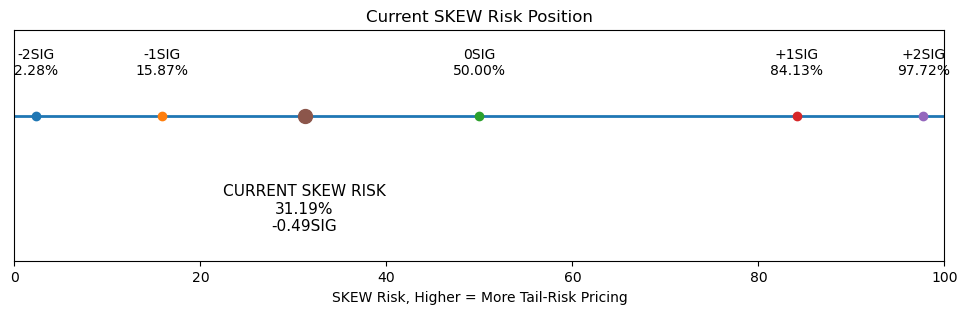

In [3]:

import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# =========================
# SKEW Risk Model
# Completed months use month-end closes.
# The current month uses the latest available SKEW close as a provisional month-end close.
# Risk increases as SKEW rises.
# Step 4: SKEW Risk = NORMDIST(...)
# =========================

today = RUN_TIMESTAMP_UTC.tz_localize(None).normalize()

# Download 21 years because Steps 2 and 3 each require a 10-year rolling window.
start_date = today - relativedelta(years=21)

# Download daily SKEW data
daily = yf.download(
    "^SKEW",
    start=start_date.strftime("%Y-%m-%d"),
    end=(today + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Flatten yfinance MultiIndex columns when present
if isinstance(daily.columns, pd.MultiIndex):
    daily.columns = daily.columns.get_level_values(0)

# Use only the Close column
daily = daily[["Close"]].dropna()
daily = daily.rename(columns={"Close": "SKEW_Close"})

# Latest available SKEW close
latest_date = daily.index[-1]
latest_skew = daily["SKEW_Close"].iloc[-1]

# Build the monthly close series
monthly = daily.resample("ME").last()

# Use the latest available SKEW close as the provisional close for the current month.
current_month_end = today + pd.offsets.MonthEnd(0)
monthly.loc[current_month_end, "SKEW_Close"] = latest_skew

# Step 1: Log SKEW
monthly["Log_SKEW"] = np.log(monthly["SKEW_Close"])

# Step 2: 10-year rolling mean of log values
monthly["Log_10Y_Avg"] = monthly["Log_SKEW"].rolling(120).mean()

# Step 2: Relative deviation from the rolling log mean
monthly["Log_Deviation"] = (
    monthly["Log_SKEW"] - monthly["Log_10Y_Avg"]
) / monthly["Log_10Y_Avg"]

# Step 3: 10-year rolling mean and standard deviation of the deviation
# Adjust for SKEW's structural upward trend at this stage.
monthly["Dev_10Y_Avg"] = monthly["Log_Deviation"].rolling(120).mean()
monthly["Dev_10Y_Std"] = monthly["Log_Deviation"].rolling(120).std()

# Z-score
monthly["Z_Score"] = (
    monthly["Log_Deviation"] - monthly["Dev_10Y_Avg"]
) / monthly["Dev_10Y_Std"]

# Step 4: SKEW Risk = NORMDIST
# Higher SKEW implies higher risk, so no complement (1 -) is applied.
monthly["SKEW_Risk"] = norm.cdf(monthly["Z_Score"])

# Latest complete model row
latest_row = monthly.dropna().iloc[-1]

z_current = latest_row["Z_Score"]
current_risk = latest_row["SKEW_Risk"] * 100

# Sigma reference levels
sigma_levels = {
    "-2SIG": norm.cdf(-2) * 100,
    "-1SIG": norm.cdf(-1) * 100,
    "0SIG":  norm.cdf(0) * 100,
    "+1SIG": norm.cdf(1) * 100,
    "+2SIG": norm.cdf(2) * 100,
}

# =========================
# Display results
# =========================

print("As of:", today.date())
print("Latest SKEW date used:", latest_date.date())
print("Latest SKEW used as current-month close:", round(float(latest_skew), 4))
print("Model month:", latest_row.name.date())
print("Log Deviation:", round(float(latest_row["Log_Deviation"]), 6))
print("Deviation 10Y Avg:", round(float(latest_row["Dev_10Y_Avg"]), 6))
print("Deviation 10Y Std:", round(float(latest_row["Dev_10Y_Std"]), 6))
print("Current Z-score:", round(float(z_current), 4))
print("Current SKEW Risk:", round(float(current_risk), 2), "%")

# =========================
# Visualization
# =========================

plt.figure(figsize=(12, 3))
plt.hlines(1, 0, 100, linewidth=2)

for label, x in sigma_levels.items():
    plt.plot(x, 1, marker="o")
    plt.text(
        x, 1.08,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.plot(current_risk, 1, marker="o", markersize=10)
plt.text(
    current_risk,
    0.86,
    f"CURRENT SKEW RISK\n{current_risk:.2f}%\n{z_current:.2f}SIG",
    ha="center",
    va="top",
    fontsize=11
)

plt.xlim(0, 100)
plt.ylim(0.7, 1.18)
plt.yticks([])
plt.xlabel("SKEW Risk, Higher = More Tail-Risk Pricing")
plt.title("Current SKEW Risk Position")
plt.show()

Latest CAPE date: 2026-07-29
Latest Shiller PE / CAPE: 39.93
10Y CAPE Avg: 32.3867
Deviation: 0.232912
Deviation 10Y Avg: 0.194418
Deviation 10Y Std: 0.119119
Current Z-score: 0.3232
Current Valuation Risk: 62.67 %


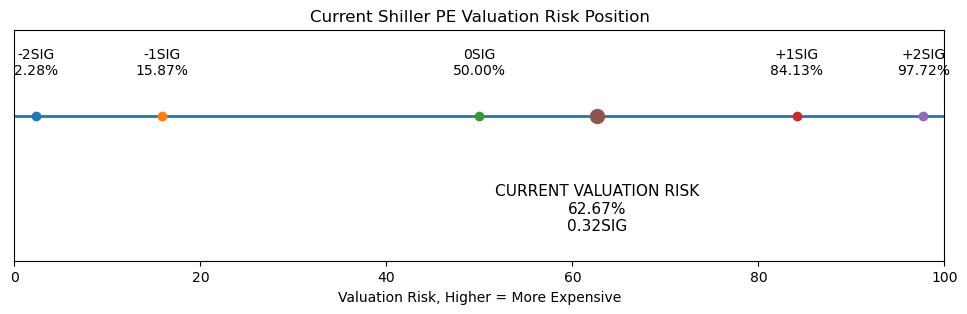

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# =========================
# Shiller PE / CAPE Valuation Risk Model
# Step 1: Calculate deviation from the 10-year rolling mean
# Step 2: Adjust the trend using the deviation's 10-year rolling mean and standard deviation
# Step 3: Valuation Risk = NORMDIST(...)
# Higher values indicate a more expensive equity market.
# =========================

url = "https://www.multpl.com/shiller-pe/table/by-month"

# Download the HTML table from Multpl
tables = pd.read_html(url)
cape = tables[0].copy()

# Standardize column names
cape.columns = ["Date", "Shiller_PE"]

# Convert numeric and date fields
cape["Date"] = pd.to_datetime(cape["Date"], errors="coerce")
cape["Shiller_PE"] = (
    cape["Shiller_PE"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"([0-9]+\.?[0-9]*)")[0]
    .astype(float)
)

cape = cape.dropna().sort_values("Date")
cape["Month"] = cape["Date"].dt.to_period("M")
cape = cape.drop_duplicates("Month", keep="last")
cape = cape.set_index("Date")[["Shiller_PE"]]

# Treat the data as a monthly series
monthly = cape.copy()
monthly = monthly.rename(columns={"Shiller_PE": "CAPE"})

# Use the same canonical CAPE transformation as the validation notebook.
monthly = compute_cape_risk_frame(monthly, value_col="CAPE", window=120)

# Latest complete model row
latest_row = monthly.dropna().iloc[-1]

z_current = latest_row["Z_Score"]
current_risk = latest_row["Normal_Risk_Score"] * 100

# Sigma reference levels
sigma_levels = {
    "-2SIG": norm.cdf(-2) * 100,
    "-1SIG": norm.cdf(-1) * 100,
    "0SIG":  norm.cdf(0) * 100,
    "+1SIG": norm.cdf(1) * 100,
    "+2SIG": norm.cdf(2) * 100,
}

# =========================
# Display results
# =========================

print("Latest CAPE date:", latest_row.name.date())
print("Latest Shiller PE / CAPE:", round(float(latest_row["CAPE"]), 4))
print("10Y CAPE Avg:", round(float(latest_row["CAPE_10Y_Avg"]), 4))
print("Deviation:", round(float(latest_row["CAPE_Deviation"]), 6))
print("Deviation 10Y Avg:", round(float(latest_row["Dev_10Y_Avg"]), 6))
print("Deviation 10Y Std:", round(float(latest_row["Dev_10Y_Std"]), 6))
print("Current Z-score:", round(float(z_current), 4))
print("Current Valuation Risk:", round(float(current_risk), 2), "%")

# =========================
# Visualization
# =========================

plt.figure(figsize=(12, 3))
plt.hlines(1, 0, 100, linewidth=2)

for label, x in sigma_levels.items():
    plt.plot(x, 1, marker="o")
    plt.text(
        x,
        1.08,
        f"{label}\n{x:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.plot(current_risk, 1, marker="o", markersize=10)
plt.text(
    current_risk,
    0.86,
    f"CURRENT VALUATION RISK\n{current_risk:.2f}%\n{z_current:.2f}SIG",
    ha="center",
    va="top",
    fontsize=11
)

plt.xlim(0, 100)
plt.ylim(0.7, 1.18)
plt.yticks([])
plt.xlabel("Valuation Risk, Higher = More Expensive")
plt.title("Current Shiller PE Valuation Risk Position")
plt.show()